# load things for science :)

In [ ]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
import matplotlib.pyplot
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.cm
import math
import sys
import csv
import itertools
from scipy import integrate
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path
import uproot
from scipy.ndimage import gaussian_filter1d
from scipy.optimize import curve_fit
from IPython.display import display, clear_output

# load root

In [71]:
# change folder name to 'experiment' or 'simulation' or 'threepion_sim'
folder_name = "simulation"

# options are fall18_inb, fall18_outb, spring19_inb, spring19_inb_noBG, spring19_inb_50nA_noSmearing, spring19_inb_50nA,  so far
data_name = "spring19_inb_50nA"

# options include EXCL, mPim, mPip, mProt
topology_name = "EXCL"

# choose files for analysis
# sim_root = uproot.open("/Users/aosmond/nuclearPhys/root/finished_root/sp19inb/simulation/10_2rec_excl_sp19inb_50nA_local_06_26_2026_12.root", index_col=False)["events"].arrays(library="pd")
# sim_root = uproot.open("/Users/aosmond/nuclearPhys/root/finished_root/sp19inb/simulation/10_2rec_excl_sp19inb_test2_jlab_07_16_2026.root", index_col=False)["events"].arrays(library="pd")
sim_root = uproot.open("/Users/aosmond/nuclearPhys/root/finished_root/10_2rec_excl_sp19inb_50nA_local_07_16_2026_test7_3th.root", index_col=False)["events"].arrays(library="pd")

exp_root = uproot.open("/Users/aosmond/nuclearPhys/root/finished_root/sp19inb/experiment/10_2exp_excl_sp19inb_pass2_jlab_07_08_2026_2.root", index_col=False)["events"].arrays(library="pd")

threepion_root = uproot.open("/Users/aosmond/nuclearPhys/root/finished_root/sp19inb/simulation/10_2rec_excl_3pi_sp19inb_50nA_jlab_07_15_2026.root", index_col=False)["events"].arrays(library="pd")

# base path for future hists
hist_base_path = Path(f'/Users/aosmond/nuclearPhys/notebooks/notebook_hists_fromRoot/{folder_name}/{data_name}/{topology_name}_topology')

In [72]:
sim_root.head()

,event,w,q2,weight,pid_prot_rec,pid_pip_rec,pid_pim_rec,pid_prot_mc,pid_pip_mc,pid_pim_mc,...,excl_mom,pim_theta_miss,pim_theta_meas,pip_theta_miss,pip_theta_meas,prot_theta_miss,prot_theta_meas,pim_theta_angle_btwn_P,pip_theta_angle_btwn_P,prot_theta_angle_btwn_P
0,0,2.362762,4.764036,0.000029,2212,211,-211,2212,211,-211,...,0.160258,91.959122,72.899429,12.263130,12.448850,19.764206,18.192223,19.219353,0.930364,2.732494
1,0,1.505193,4.591867,0.000014,2212,211,-211,2212,211,-211,...,0.094490,31.501228,32.785122,44.228436,48.598164,25.243019,25.170349,2.518878,4.424494,0.109001
2,0,2.481305,3.269031,0.000158,2212,211,-211,2212,211,-211,...,0.279853,27.630575,47.433739,6.838033,9.090587,28.844057,36.877163,21.996145,2.438279,8.174057
3,0,2.034224,5.635994,0.000011,2212,211,-211,2212,211,-211,...,0.259802,21.341528,30.828323,38.900719,52.605366,15.057312,15.767465,9.778531,13.793792,0.810945
4,0,1.324075,6.722647,0.000002,2212,211,-211,2212,211,-211,...,0.077410,28.007845,30.019012,28.015194,30.107443,20.704901,21.737358,6.601112,3.232771,1.525494


In [73]:
sim_root.tail()

,event,w,q2,weight,pid_prot_rec,pid_pip_rec,pid_pim_rec,pid_prot_mc,pid_pip_mc,pid_pim_mc,...,excl_mom,pim_theta_miss,pim_theta_meas,pip_theta_miss,pip_theta_meas,prot_theta_miss,prot_theta_meas,pim_theta_angle_btwn_P,pip_theta_angle_btwn_P,prot_theta_angle_btwn_P
1234395,0,1.039024,4.490784,0.000004,2212,211,-211,2212,211,-211,...,0.421501,103.768906,48.996063,67.542885,34.775661,31.036926,24.601603,56.153091,34.270859,7.481904
1234396,0,1.980163,7.080744,0.000004,2212,211,-211,2212,211,-211,...,0.082730,19.399216,18.170649,72.036880,72.874374,15.782729,14.679358,1.594784,5.416102,1.124453
1234397,0,2.125344,7.140681,0.000004,2212,211,-211,2212,211,-211,...,0.757604,12.928805,39.382969,8.053025,16.895372,13.515754,18.205948,26.513741,13.571407,4.696888
1234398,0,2.257224,6.187299,0.000034,2212,211,-211,2212,211,-211,...,0.183214,15.573944,16.864428,14.226727,15.721316,25.708431,28.054762,1.299411,1.573223,2.387639
1234399,0,1.707086,6.276463,0.000005,2212,211,-211,2212,211,-211,...,0.128843,30.059021,37.037453,22.194227,23.998804,13.875896,15.378799,6.978802,1.804579,1.503120


In [60]:
exp_root.head()

,event,w,q2,weight,pid_prot_rec,pid_pip_rec,pid_pim_rec,pid_prot_mc,pid_pip_mc,pid_pim_mc,...,excl_mom,pim_theta_miss,pim_theta_meas,pip_theta_miss,pip_theta_meas,prot_theta_miss,prot_theta_meas,pim_theta_angle_btwn_P,pip_theta_angle_btwn_P,prot_theta_angle_btwn_P
0,0,2.292130,2.063685,1.0,2212,211,-211,-999,-999,-999,...,0.025624,46.814552,47.595161,29.589993,30.420931,11.612651,11.510756,0.874471,0.883950,0.126736
1,0,2.393109,2.952282,1.0,2212,211,-211,-999,-999,-999,...,0.624286,29.775385,33.383587,15.765433,26.257166,20.629251,19.998119,3.769303,14.038247,0.757327
2,0,1.777695,3.722266,1.0,2212,211,-211,-999,-999,-999,...,0.068191,27.971191,30.035698,59.351521,68.233444,16.327551,17.359282,2.075666,9.107581,1.031775
3,0,1.958665,3.098960,1.0,2212,211,-211,-999,-999,-999,...,0.037285,47.846760,45.671074,28.863708,28.166794,17.745592,17.698475,2.483378,0.774209,0.362328
4,0,2.304656,2.281736,1.0,2212,211,-211,-999,-999,-999,...,0.271868,29.454464,38.398804,16.553877,17.932484,27.719254,32.743652,9.161918,1.397170,5.031284


In [61]:
exp_root.tail()

,event,w,q2,weight,pid_prot_rec,pid_pip_rec,pid_pim_rec,pid_prot_mc,pid_pip_mc,pid_pim_mc,...,excl_mom,pim_theta_miss,pim_theta_meas,pip_theta_miss,pip_theta_meas,prot_theta_miss,prot_theta_meas,pim_theta_angle_btwn_P,pip_theta_angle_btwn_P,prot_theta_angle_btwn_P
6091644,0,1.918260,2.046328,1.0,2212,211,-211,-999,-999,-999,...,0.017180,33.424545,33.029327,52.699692,49.583237,11.367807,10.550490,0.515883,3.170338,0.820246
6091645,0,1.832414,2.883022,1.0,2212,211,-211,-999,-999,-999,...,0.037733,40.112019,39.112232,17.536118,15.972836,24.029655,23.470467,1.441017,1.675226,1.397674
6091646,0,2.195808,3.205842,1.0,2212,211,-211,-999,-999,-999,...,0.823326,16.161867,71.813164,12.088041,23.482237,15.187396,23.057001,56.184536,11.458829,7.870580
6091647,0,2.338025,2.684567,1.0,2212,211,-211,-999,-999,-999,...,0.019677,18.495480,18.179333,12.600471,11.861180,44.854572,43.366718,0.471936,0.829090,1.536167
6091648,0,2.474596,4.080697,1.0,2212,211,-211,-999,-999,-999,...,3.112647,17.445421,62.330841,21.629860,18.117647,19.348940,12.074853,74.815414,4.593458,12.975735


In [62]:
threepion_root.head()

,event,w,q2,weight,pid_prot_rec,pid_pip_rec,pid_pim_rec,pid_prot_mc,pid_pip_mc,pid_pim_mc,...,excl_mom,pim_theta_miss,pim_theta_meas,pip_theta_miss,pip_theta_meas,prot_theta_miss,prot_theta_meas,pim_theta_angle_btwn_P,pip_theta_angle_btwn_P,prot_theta_angle_btwn_P
0,0,1.724905,2.955294,0.021026,2212,211,-211,211,211,-211,...,1.520312,113.571510,58.828526,10.283901,38.992672,12.838315,39.697048,80.762604,32.749126,28.736111
1,0,2.361620,4.057083,0.085943,2212,211,-211,-211,211,-211,...,3.262042,31.781668,39.154202,39.782173,45.633629,23.070873,32.687443,45.692383,52.282955,54.644867


In [63]:
threepion_root.tail()

,event,w,q2,weight,pid_prot_rec,pid_pip_rec,pid_pim_rec,pid_prot_mc,pid_pip_mc,pid_pim_mc,...,excl_mom,pim_theta_miss,pim_theta_meas,pip_theta_miss,pip_theta_meas,prot_theta_miss,prot_theta_meas,pim_theta_angle_btwn_P,pip_theta_angle_btwn_P,prot_theta_angle_btwn_P
0,0,1.724905,2.955294,0.021026,2212,211,-211,211,211,-211,...,1.520312,113.571510,58.828526,10.283901,38.992672,12.838315,39.697048,80.762604,32.749126,28.736111
1,0,2.361620,4.057083,0.085943,2212,211,-211,-211,211,-211,...,3.262042,31.781668,39.154202,39.782173,45.633629,23.070873,32.687443,45.692383,52.282955,54.644867


In [64]:
w_min = sim_root["w"].min()
w_max = sim_root["w"].max()

q2_min = sim_root["q2"].min()
q2_max = sim_root["q2"].max()

print("w min:", w_min)
print("w max:", w_max)
print("q2 min:", q2_min)
print("q2 max:", q2_max)


w min: 1.0002842
w max: 2.4999971
q2 min: 1.5937573
q2 max: 11.996884


In [65]:
bins_value = 100
step = 0.001

# --- Define MM² ranges for each topology ---
topologies = {
    "excl": (-0.03, 0.03),
    "mProt": (-0.1, 2.5),
    "mPip": (-0.4, 0.6),
    "mPim": (-0.4, 0.6),
}

# determine mismatches

In [66]:
# Force PID columns to integers
pid_cols = [
    "pid_prot_rec", "pid_prot_mc",
    "pid_pip_rec",  "pid_pip_mc",
    "pid_pim_rec",  "pid_pim_mc"
]

for col in pid_cols:
    sim_root[col] = pd.to_numeric(sim_root[col], errors="coerce").astype(int)

# Sequential mismatch logic
conditions = [
    sim_root["pid_prot_mc"] != sim_root["pid_prot_rec"],

    (sim_root["pid_prot_mc"] == sim_root["pid_prot_rec"]) &
    (sim_root["pid_pip_mc"] != sim_root["pid_pip_rec"]),

    (sim_root["pid_prot_mc"] == sim_root["pid_prot_rec"]) &
    (sim_root["pid_pip_mc"] == sim_root["pid_pip_rec"]) &
    (sim_root["pid_pim_mc"] != sim_root["pid_pim_rec"])
]

choices = [
    "prot_mismatch",
    "pip_mismatch",
    "pim_mismatch"
]

sim_root["match_category"] = np.select(
    conditions,
    choices,
    default="matched"
)

# Counts
print(sim_root["match_category"].value_counts())

match_category
matched          200984
pip_mismatch       2554
pim_mismatch       1137
prot_mismatch       606
Name: count, dtype: int64


# w-q2 range

In [67]:
# w and q2 ranges
w_bins = np.append(np.arange(1.4, 2.5, 0.05), 2.5)
q2_bins = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0] ## original range was 8,9,11,13 but I added finer binning (?)
# q2_bins = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0] 

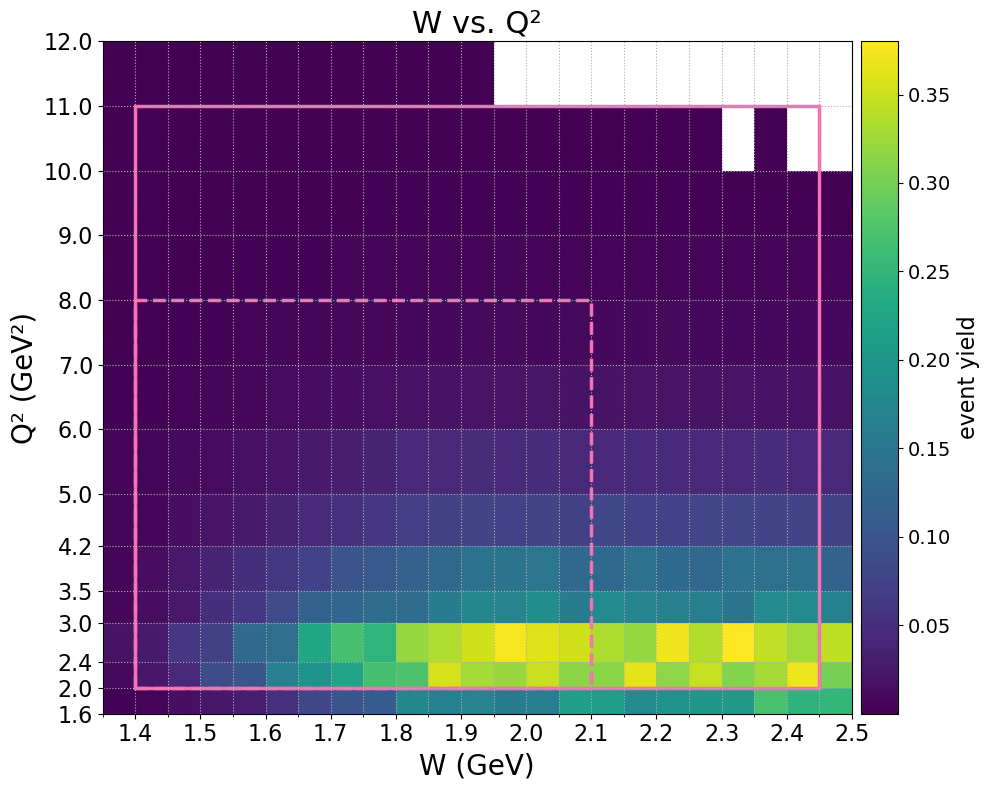

In [68]:
w_range = np.append(np.arange(1.35, 2.5, 0.05), 2.5)
q2_range = [1.6,2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0] #,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0,21.0,22.0]

###### fine bins
n_w_bins  = 300  #500
n_q2_bins = 300

w_min, w_max   = 1.35, 2.50
q2_min, q2_max = 1.6, 12.0

# --- W vs Q² histograms with colorbars for each topology ---
# Define bin edges from your ranges
bin_x = w_range
bin_y = q2_range

# for topo in topologies:
fig, ax = plt.subplots(figsize=(10, 8))
mask = sim_root["w"].notna() & sim_root["q2"].notna()
w_vals = sim_root.loc[mask, "w"].to_numpy()
q2_vals = sim_root.loc[mask, "q2"].to_numpy()
weights = sim_root.loc[mask, "weight"].to_numpy()

# 2D histogram — color represents event density
h = ax.hist2d(w_vals, q2_vals, bins=[bin_x, bin_y], cmap='viridis', cmin=1e-12, weights=weights, density=False)

# Title and axes
ax.set_title(f"W vs. Q²", fontsize=22)
ax.set_xlabel("W (GeV)", fontsize=20)
ax.set_ylabel("Q² (GeV²)", fontsize=20)

# Colorbar setup
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.09)
cb = plt.colorbar(h[3], cax=cax)
cb.set_label("event yield", fontsize=16)
cb.ax.tick_params(labelsize=14)

# Grid and ticks
ax.grid(which='both', linestyle=':')
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_xticks(np.append(np.arange(1.4, 2.5, 0.1), 2.5))
ax.set_xticks(bin_x, minor=True) 
ax.set_yticks(bin_y)

# Define analyzed range
w_min_analyzed, w_max_analyzed = 1.4, 2.45
q2_min_analyzed, q2_max_analyzed = 2.0, 11.0

# Create a red rectangle
rect = patches.Rectangle(
    (w_min_analyzed, q2_min_analyzed),  # bottom-left corner
    w_max_analyzed - w_min_analyzed,    # width
    q2_max_analyzed - q2_min_analyzed,  # height
    linewidth=2.5, edgecolor='hotpink', alpha=1.0, facecolor='none')

# Define analyzed range
w_min_analyzed_krishna, w_max_analyzed_krishna = 1.4, 2.10
q2_min_analyzed_krishna, q2_max_analyzed_krishna = 2.0, 8.0

# Create a red rectangle
rect_krishna = patches.Rectangle(
    (w_min_analyzed_krishna, q2_min_analyzed_krishna),  # bottom-left corner
    w_max_analyzed_krishna - w_min_analyzed_krishna,    # width
    q2_max_analyzed_krishna - q2_min_analyzed_krishna,  # height
    linewidth=2.5, edgecolor='hotpink', alpha=1.0, linestyle='--', facecolor='none')

# Add rectangle to the axes
ax.add_patch(rect)
ax.add_patch(rect_krishna)

plt.tight_layout()
plt.show()

# w-q2 binned cuts

In [69]:
# w and q2 ranges
w_bins = np.append(np.arange(1.4, 2.5, 0.05), 2.5)
q2_bins = [2.0,2.4,3.0,3.5,4.2,5.0,6.0,7.0,8.0,9.0,10.0,11.0] #,13.0]

In [70]:
# --- Initialize cut_results for all systematic cuts ---
cut_results = {
    "mm2": {"in": {}, "out": {}, "all": {}},
    "theta": {"in": {}, "out": {}, "all": {}},
    "momentum": {"in": {}, "out": {}, "all": {}}
}

# mm2 misID

In [ ]:
binned_hist_path = Path("MM2_binned_wq2/mm2_misID_withexp_simscaled")
bins_value = 100

# --- Gaussian function ---
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# --- Define MM² topologies ---
topologies_mm2 = {
    # "excl":  {"range": (-0.03, 0.03), "fit_window": (-0.02, 0.02)},
    # "mProt": {"range": (-0.1, 2.5),   "fit_window": (0.4, 1.25)},
    # "mPip":  {"range": (-0.4, 0.6),   "fit_window": (-0.3, 0.2)},
    # "mPim":  {"range": (-0.4, 0.6),   "fit_window": (-0.3, 0.2)},
    "excl":  {"range": (-0.03, 0.03), "fit_window": (-0.02, 0.02)},
    "mProt": {"range": (-0.1, 2.5),   "fit_window": (0.4, 1.25)},
    # "mProt": {"range": (-0.1, 0.5),   "fit_window": (-0.1, 0.5)},
    "mPip":  {"range": (-0.3, 0.3),   "fit_window": (-0.3, 0.3)},
    # "mPip":  {"range": (-0.6, -0.1),   "fit_window": (-0.6, -0.1)},
    "mPim":  {"range": (-0.3, 0.3),   "fit_window": (-0.3, 0.3)},
    # "mPim":  {"range": (-0.6, -0.1),   "fit_window": (-0.6, -0.1)},
}

# ==========================================
# Choose which events to plot
# ==========================================

# # options: mismatch, matched, all
# plot_type = "all"

# if plot_type == "mismatch":
#     sim_root = sim_root[sim_root["match_category"] != "matched"].copy()

# elif plot_type == "matched":
#     sim_root = sim_root[sim_root["match_category"] == "matched"].copy()

# elif plot_type == "all":
#     sim_root = sim_root.copy()

# else:
#     raise ValueError(f"Unknown plot_type: {plot_type}")

# print(f"\nPlot type: {plot_type}")
print(f"Events used: {len(sim_root)}")

sim_root['w_bin'] = pd.cut(sim_root['w'], bins=w_bins, labels=False, right=False)
sim_root['q2_bin'] = pd.cut(sim_root['q2'], bins=q2_bins, labels=False, right=False)
binned_data = sim_root.dropna(subset=['w_bin', 'q2_bin'])

exp_root['w_bin'] = pd.cut(exp_root['w'], bins=w_bins, labels=False, right=False)
exp_root['q2_bin'] = pd.cut(exp_root['q2'], bins=q2_bins, labels=False, right=False)
exp_binned_data = exp_root.dropna(subset=['w_bin', 'q2_bin'])

threepion_root['w_bin'] = pd.cut(threepion_root['w'], bins=w_bins, labels=False, right=False)
threepion_root['q2_bin'] = pd.cut(threepion_root['q2'], bins=q2_bins, labels=False, right=False)
threepion_binned_data = threepion_root.dropna(subset=['w_bin', 'q2_bin'])

# --- Helpers ---
def bin_label(bin_idx, bin_edges):
    if bin_idx < len(bin_edges) - 1:
        return f"[{bin_edges[bin_idx]:.2f}, {bin_edges[bin_idx + 1]:.2f})"
    return "[out of range)"

def safe_str(label):
    return label.strip("[]()").replace(",", "_").replace(" ", "")

# sigma_factors = np.arange(0.5, 1.75 + 0.001, 0.25)
sigma_factors = [0.5, 1.5, 1.75, 2.0]
cmap = plt.cm.rainbow_r
sigma_colors = cmap(np.linspace(0, 1, len(sigma_factors)))

# --- Process a single (W,Q2) bin ---
def process_bin(group, w_bin, q2_bin, topo, sigma=1.1775):
    """Process a single (w,q2) bin with Gaussian fit cuts for a given MM² topology."""
    w_label = bin_label(w_bin, w_bins)
    q2_label = bin_label(q2_bin, q2_bins)
    column = f"mm2_{topo}"
    x_min, x_max = topologies_mm2[topo]["range"]

    # Histogram over plotting range
    values, bins = np.histogram(group[column].dropna(), bins=bins_value, range=(x_min, x_max))
    bin_centers = (bins[:-1] + bins[1:]) / 2.0

    # initialize fit & cut results
    amp_fit = mean_fit = sigma_fit = None
    left_out = right_out = left_in = right_in = None

    all_group = group.copy()
    mismatch_group = group[group["match_category"] != "matched"]
    matched_group = group[group["match_category"] == "matched"]

    n_all = len(all_group)
    n_mismatch = len(mismatch_group)
    n_matched = len(matched_group)

    exp_group = exp_binned_data[
        (exp_binned_data["w_bin"] == w_bin) &
        (exp_binned_data["q2_bin"] == q2_bin)
    ]

    n_exp = len(exp_group)

    threepion_group = threepion_binned_data[
        (threepion_binned_data["w_bin"] == w_bin) &
        (threepion_binned_data["q2_bin"] == q2_bin)
    ]

    threepion_vals = threepion_group[column].dropna()
    n_3pi = len(threepion_group)

    try:
        # --- get user-provided fit window (must be tuple (left, right)) ---
        fit_window = topologies_mm2[topo].get("fit_window", None)
        if fit_window is None:
            raise ValueError(f"No fit_window defined for topology '{topo}'")

        if not (isinstance(fit_window, tuple) and len(fit_window) == 2):
            raise ValueError(f"fit_window for '{topo}' must be a tuple (left, right)")

        fit_window_left, fit_window_right = fit_window

    except Exception as e:
        print(f"Skipping bad bin -> {topo}, W-bin {w_bin}, Q2-bin {q2_bin}: {e}")
        return

    sim_vals = all_group[column].dropna()
    exp_vals = exp_group[column].dropna()

    # only count events inside plotting range
    sim_in_range = sim_vals[
        (sim_vals >= x_min) &
        (sim_vals <= x_max)
    ]

    exp_in_range = exp_vals[
        (exp_vals >= x_min) &
        (exp_vals <= x_max)
        # (exp_vals >= fit_window_left) &
        # (exp_vals <= fit_window_right)
    ]

    threepion_in_range = threepion_vals[
        (threepion_vals >= x_min) &
        (threepion_vals <= x_max)
    ]

    sim_integral = len(sim_in_range)
    exp_integral = len(exp_in_range)
    threepion_integral = len(threepion_in_range)

    # if exp_integral > 0:
    #     exp_scale = sim_integral / exp_integral
    # else:
    #     exp_scale = 1.0

    if sim_integral > 0:
        sim_scale = exp_integral / sim_integral
    else:
        sim_scale = 1.0

    if threepion_integral > 0:
        threepion_scale = sim_integral / threepion_integral
    else:
        threepion_scale = 1.0

    # --- Plot results ---
    plt.figure(figsize=(11, 7))
    
    # --- ALL EVENTS ---
    plt.hist(
        all_group[column].dropna(),
        bins=bins_value,
        range=(x_min, x_max),
        histtype='step',
        linewidth=1.0,
        color='black',
        weights=np.ones(len(all_group[column].dropna())) * sim_scale,
        label=f"all events, scaled (N={n_all})"
    )

    # --- MISMATCH EVENTS ---
    plt.hist(
        mismatch_group[column].dropna(),
        bins=bins_value,
        range=(x_min, x_max),
        histtype='step',
        linewidth=1.0,
        linestyle='--',
        color='red',
        weights=np.ones(len(mismatch_group[column].dropna())) * sim_scale,
        label=f"mismatches (N={n_mismatch})"
    )

    # --- MATCHED EVENTS ---
    plt.hist(
        matched_group[column].dropna(),
        bins=bins_value,
        range=(x_min, x_max),
        histtype='step',
        linewidth=1.0,
        linestyle='--',
        color='green',
        weights=np.ones(len(matched_group[column].dropna())) * sim_scale,
        label=f"matches (N={n_matched})"
    )

    # --- EXPERIMENT (scaled to simulation integral) ---
    if len(exp_vals) > 0:

        plt.hist(
            exp_vals,
            bins=bins_value,
            range=(x_min, x_max),
            histtype='step',
            linewidth=1.0,
            linestyle='--',
            color='blue',
            # weights=np.ones(len(exp_vals)) * exp_scale,
            label=f"exp (N={n_exp})" #, scale={exp_scale:.2f})"
        )   
        
    # --- THREE PION (scaled to experiment integral) ---
    plt.hist(
        threepion_vals,
        bins=bins_value,
        range=(x_min, x_max),
        histtype='step',
        linewidth=1.0,
        linestyle='--',
        color='purple',
        weights=np.ones(len(threepion_vals)) * threepion_scale,
        label=f"3π scaled (N={n_3pi})" #, scale={exp_scale:.2f})"
    )

    # # --- Plot multiple in-cuts ---
    # for i, sigma in enumerate(sigma_factors):
    #     left = mean_fit - sigma * sigma_fit
    #     right = mean_fit + sigma * sigma_fit

    #     color = sigma_colors[i]
    #     lw = 1.2
    #     alpha = 0.9

    # Title & labels
    plt.title(f"{topo} MM²: W {w_label}, Q² {q2_label}", fontsize=25)
    plt.xlabel('MM² [GeV²]', fontsize=20)
    plt.xlim(x_min, x_max)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.grid(alpha=0.5)
    plt.legend(fontsize=12, loc='upper right')

    # Save figure
    # outdir = hist_base_path / binned_hist_path / f"mm2cuts_{topo}_{plot_type}"
    outdir = hist_base_path / binned_hist_path / f"mm2cuts_{topo}"
    outdir.mkdir(parents=True, exist_ok=True)
    fname = outdir / f"mm2_W_{safe_str(w_label)}_Q2_{safe_str(q2_label)}.png"
    plt.savefig(fname, dpi=300)
    plt.close()

# --- Main loop over MM² topologies ---
for topo in topologies_mm2:
    total_bins = binned_data.groupby(['w_bin', 'q2_bin']).ngroups
    for i, ((w_bin, q2_bin), group) in enumerate(binned_data.groupby(['w_bin', 'q2_bin']), start=1):
        process_bin(group, int(w_bin), int(q2_bin), topo, sigma=3.0)
        print(f"{topo}: Saved histogram {i}/{total_bins} ({i/total_bins*100:.2f}% complete)", end="\r")
        sys.stdout.flush()
    print()  # new line after each topo


Plot type: all
Events used: 1235874
excl: Saved histogram 239/239 (100.00% complete)
mProt: Saved histogram 239/239 (100.00% complete)
mPip: Saved histogram 239/239 (100.00% complete)
mPim: Saved histogram 239/239 (100.00% complete)
